In [1]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel,Field
import time

from langchain_community.document_loaders import PyPDFLoader,JSONLoader
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

g:\Genarative-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
from langchain_community.document_loaders import PyPDFLoader
from llama_index.core.vector_stores import MetadataInfo, VectorStoreInfo
from llama_index.core.retrievers import VectorIndexAutoRetriever
from metadata_making_fun import*

In [3]:


teachers_data = JSONLoader(
        file_path='.\\Document\\teachers_data.json',

        jq_schema='.[]', 
        content_key= 'context_text',
        metadata_func= metadata_for_teacher
    ).load()

staff_data=JSONLoader(
        file_path='.\\Document\\staff_data.json',

        jq_schema='.[]', 
        content_key= 'context_text',
        metadata_func= metadata_for_staff
    ).load() 

r_dev_data =JSONLoader(
        file_path='.\\Document\\Recent_Development.json',

        jq_schema='.[]', 
        content_key= 'context_text',
        metadata_func= metadata_for_recent_dev
    ).load() 

overvew_data=JSONLoader(
        file_path='.\\Document\\Overview.json',

        jq_schema='.[]', 
        content_key= 'context_text',
        metadata_func= metadata_for_overvew
    ).load() 


mission_data=JSONLoader(
        file_path='.\\Document\\Mission_Vision.json',

        jq_schema='.[]', 
        content_key= 'context_text',
        metadata_func= metadata_for_mission
    ).load() 


lab_data=JSONLoader(
        file_path='.\\Document\\labinfo.json',

        jq_schema='.[]', 
        content_key= 'context_text',
        metadata_func= metadata_for_labinfo
    ).load() 

f_dev_data=JSONLoader(
        file_path='.\\Document\\Future_Development.json',

        jq_schema='.[]', 
        content_key= 'context_text',
        metadata_func= metadata_for_future_dev
    ).load() 


class_rutine_data=JSONLoader(
        file_path='.\\Document\\class_rutine.json',

        jq_schema='.[]', 
        content_key= 'context_text',
        metadata_func= metadata_for_class_rutine
    ).load() 


docs = teachers_data + staff_data + r_dev_data + overvew_data + mission_data + lab_data + f_dev_data + class_rutine_data

print(len(docs))
print(docs[0])

162
page_content='মোঃ ওমর ফারুক হলেন (চাঁপাইনবাবগঞ্জ পলিটেকনিক ইনস্টিটিউট / CNPI)-এর অধ্যক্ষ / principal / Headmaster / college prodhan (অতিরিক্ত দায়িত্ব)। তার পদবি হলো অধ্যক্ষ / Principal (অতিরিক্ত দায়িত্ব)। তিনি অতিরিক্ত দায়িত্ব বিভাগে কর্মরত আছেন। তার সাথে যোগাযোগ করতে পারবেন এই নম্বরে: ০১৭১১২৬২৩২৮। মোঃ ওমর ফারুক-এর ফোন নম্বর ০১৭১১২৬২৩২৮। যদি কেউ অতিরিক্ত দায়িত্ব বিভাগের শিক্ষকদের তথ্য জানতে চান, তাহলে মোঃ ওমর ফারুক (অধ্যক্ষ (অতিরিক্ত দায়িত্ব)) একজন গুরুত্বপূর্ণ যোগাযোগ ব্যক্তি।' metadata={'source': 'G:\\Genarative-AI\\Self Rag\\Backend\\Document\\teachers_data.json', 'seq_num': 1, 'name': 'মোঃ ওমর ফারুক', 'designation': 'অধ্যক্ষ (অতিরিক্ত দায়িত্ব)', 'dipertment': 'অতিরিক্ত দায়িত্ব', 'phone': '০১৭১১২৬২৩২৮', 'doc_type': 'teachers info', 'context_text': 'মোঃ ওমর ফারুক হলেন (চাঁপাইনবাবগঞ্জ পলিটেকনিক ইনস্টিটিউট / CNPI)-এর অধ্যক্ষ / principal / Headmaster / college prodhan (অতিরিক্ত দায়িত্ব)। তার পদবি হলো অধ্যক্ষ / Principal (অতিরিক্ত দায়িত্ব)। তিনি অতিরিক্ত দায়িত্ব বিভাগে কর্মরত আছেন।

In [4]:
# chunks = RecursiveCharacterTextSplitter(chunk_size = 600,chunk_overlap = 150).split_documents(docs)
# print(len(chunks))

In [4]:
embed_model = HuggingFaceEmbeddings(model="BAAI/bge-m3")


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 3666.24it/s]


In [5]:
import os
# llm = ChatGroq(
#     model="groq/compound",
#     api_key=os.getenv("GROQ_API_KEY"),
#     model_kwargs=  {'response_formate': {'type':'json_object'}}
# )

llm = ChatGroq(
    temperature=0,
    model="meta-llama/llama-4-scout-17b-16e-instruct", 
   
)

In [112]:
import lark
vector_store = Chroma(embedding_function=embed_model, persist_directory='./Vector_store')

# retriever = SelfQueryRetriever.from_llm(
#     llm=llm, 
#     vectorstore=vector_store, 
#     document_contents=document_content_description, 
#     metadata_field_info=metadata_field_info, 
#     enable_limit=True, 
#     verbose=True 
# )

retriever = vector_store.as_retriever(search_kwargs={"k": 10})

In [113]:
from typing import Annotated, TypedDict
class State(TypedDict):
    question:str

    retrieval_query: str
    rewrite_tries: int

    need_retrieval:bool

    docs:list[Document]
    relevant_docs:list[Document]
    context:str

    issup:Literal["fully_supported","partially_supported","no_support"]
    evidence:list[str]

    isuse: Literal['useful','not_useful']
    use_reason: str
    
    retries: int
    out:list
    first_ans: str
    answer: Annotated[str, lambda old, new: new]

In [114]:
class Rewrite(BaseModel):
    re_query: str = Field(..., description="Rewritten query optimized for vector retrieval.")

rewrite_prompt_1 = ChatPromptTemplate.from_messages([
  (
            "system",
            "You are a strict query optimizer for Chapainawabganj Polytechnic Institute (CNPI).\n"
            "Rewrite the user's QUESTION into a query optimized for vector retrieval.\n\n"
            "Rules:\n"
            "- Keep it short (6-16 words).\n"
            "- Preserve key entities (like CNPI, names, departments).\n"
            "- You MUST return ONLY a valid JSON object with EXACTLY one key: 're_query'. DO NOT use any other key names like 'query'.\n"
            "- Remove filler words.\n\n"
            "Examples:\n"
            "Q: 'CNPI e computer department er class routine kobe pabo?'\n"
            "-> {{\"re_query\": \"CNPI CST Computer Technology class routine schedule\"}}\n\n"
            "Q: 'Mahidul sir kon subject ney?'\n"
            "-> {{\"re_query\": \"Mahidul Islam instructor subject class details\"}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
           
        ),
])


rewrite_chain_1 = rewrite_prompt_1 | llm.with_structured_output(Rewrite, method='json_mode')



def rewrite_node_1(state:State):
    out:Rewrite = rewrite_chain_1.invoke({
        'question':state['question'],
        
        })

    return {
        'question':out.re_query,
        
    }

In [115]:
from langchain_core.output_parsers import StrOutputParser
class RetrieveDecision(BaseModel):
    should_retrieve:bool = Field(
        ...,
        description = "True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a routing expert for the Chapainawabganj Polytechnic Institute (CNPI) RAG system. "
            "Your job is to decide whether retrieving external context is needed to answer the user's question.\n\n"
            "Return ONLY a JSON object that matches this schema: {{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True MUST be strictly chosen if the query is about ANY of the following CNPI-specific topics: "
              "class routines, schedules, teachers, staff, departments, labs, contact details, recent or future developments, and institution overviews.\n"
            "- Even if the query is conversational, written in Banglish/Bengali (e.g., 'ajke robibar kar class ache', 'amader lab কয়টি?'), "
              "or lacks formal structure, choose True if it implies needing institutional data.\n"
            "- should_retrieve=False ONLY for generic greetings (e.g., 'hi', 'kemn aso'), general coding explanations, basic math, or defining universal concepts.\n"
            "- When in doubt, ALWAYS choose True."
        ),
        ("human", "Question: {question}")
    ]
)


retrieve_decied_chain = decide_retrieval_prompt | llm.with_structured_output(
    RetrieveDecision,
    method="json_mode"  
)
def decide_retrieval_node(state: State):
    decision:RetrieveDecision = retrieve_decied_chain.invoke({'question':state['question']})

    return {'need_retrieval':decision.should_retrieve}

In [116]:
class Isrelevant(BaseModel):
    is_relevant:bool = Field(
        ...,
        description='True if the document helps answer the question, else False.'
    )

Isrelevant_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',
        "You are an expert Document Relevance Grader for the Chapainawabganj Polytechnic Institute (CNPI) RAG system.\n"
        "Your task is to judge whether a retrieved document contains relevant information to answer the user's question.\n"
        "Return ONLY a JSON that matches this schema: {{'is_relevant': boolean}}\n\n"
        
        "### CRITICAL GUIDELINES FOR CNPI CONTEXT:\n"
        "1. SEMANTIC MATCHING (Banglish to English): The user often writes in conversational Banglish. You MUST gracefully map these equivalents:\n"
        "   - Departments: 'computer', 'cse', or 'cst' matches 'Computer Science & Technology / CST'. 'electrical' matches 'Electrical Technology / ET'.\n"
        "   - Time: 'bikel/sokal/dupur', '3 ta', '3tay' MUST match formal '03:00 PM' or similar AM/PM blocks in the document.\n"
        "   - Days: 'robibar', 'sombar' matches 'Sunday', 'Monday' etc. (Ignore bracket typos if the phonetic word matches).\n"
        "   - Semesters: '5th' matches 'Fifth Semester', '1st' matches 'First Semester'.\n\n"
        
        "2. ROUTINE & SCHEDULE CHECKS: If the user asks about a class schedule (e.g., 'ekar class ache', 'routine ki') "
        "and the document contains the routine for the matching department and semester, IT IS STRICTLY RELEVANT (Return True). "
        "Do not worry if the exact teacher's name isn't in the question; the document provides the context to answer it.\n\n"
        
        "3. ROLE/ENTITY CHECK: If the question explicitly asks for a person holding a specific role (e.g., 'Principal') "
        "and the document only lists someone with a completely different role without answering the query, return False. "
        "However, if the document contains info that broadly answers the query's core intent, return True.\n\n"
        
        "When in doubt, or if the document shares the same primary entities (Department + Semester + Day) as the query, ALWAYS return True."
        ),
        ('human','\nQuestion: {question}\n\nDocument:\n{document}')
    ]
)



isrelevant_chain = Isrelevant_prompt | llm.with_structured_output(Isrelevant,method='json_mode') 

def isrelevant_node(state:State):
    docs = state['docs']
    qus = state['question']
    all_docs = []
    all_docs_input = []
    relevanced_doc:list[Document] = []

    for d  in docs:
       
        all_docs_input.append({'question':qus,'document':d.page_content})
    
    all_docs_out = isrelevant_chain.batch(all_docs_input)

    for d,r in zip(docs,all_docs_out):
        if r.is_relevant:
            relevanced_doc.append(d)

    return {
        'relevant_docs': relevanced_doc,
        'out':all_docs_out
        
        }
        


In [117]:
generation_prompt = ChatPromptTemplate.from_messages([
     (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", '\nQuestion: {question}')]
        
)

genaration_chain = generation_prompt | llm | StrOutputParser()

def generation_node(state:State):
    out = genaration_chain.invoke({'question':state['question']})
    return {'answer': out, 'context': ''}

In [118]:
main_generation_prompt = ChatPromptTemplate.from_messages(
    [
         ('system',
        "You are an intelligent, very friendly, cheerful, and highly detailed RAG assistant for Chapainawabganj Polytechnic Institute (CNPI). ✨\n"
        "Your task is to answer the user's question thoroughly using ONLY the provided document context. 📚\n\n"
        
        "### STRICT RESPONSE RULES:\n"
        "1. DETAILED BUT CONTEXT-BOUND: Provide a comprehensive and detailed explanation using all relevant information from the context. Do NOT give extreme shortcut answers. However, you MUST NOT use outside knowledge or hallucinate. 🛑\n"
        "2. CHEERFUL & EMOJI-RICH TONE: Respond in clear, natural, and very happy Bengali. Use relevant emojis frequently and naturally throughout your response to make it lively (e.g., 😊, 🎓, ✨, 💻). Let your enthusiasm show!\n"
        "3. PROPERTY CHECK (CRITICAL): Check if the EXACT specific information the user is asking for is explicitly stated in the context. If the person/entity is mentioned but the SPECIFIC REQUESTED INFORMATION is missing, your answer MUST ONLY be: 'দুঃখিত, এই তথ্যটি আমার কাছে নেই 😔।' followed by the closing question from Rule 6.\n"
        "4. DO NOT GUESS OR INFER: Do not assume a workplace (like CNPI) is someone's home address.\n"
        "5. RESPECTFUL TONE: ALWAYS append the word 'স্যার' (Sir) immediately after any teacher's or instructor's name. 👨‍🏫\n"
        "6. ALWAYS OFFER FURTHER HELP: At the very end of EVERY response, you MUST ask a polite and cheerful follow-up question offering more assistance. Example: 'আমি আপনাকে আর কোনো বিষয়ে সাহায্য করতে পারি কি? 😊' or 'আপনি কি এই বিষয়ে আরও কিছু জানতে চান? ✨'\n"
),   
('human','\nQuestion: {question}\n\nDocument/Context: {context}')
    ]
)



main_generation_chain = main_generation_prompt | llm | StrOutputParser()

def main_generation_node(state:State):
    qus = state['question']
    docs = state.get('relevant_docs',[])

    context = "\n\n---\n\n".join(d.page_content for d in docs).strip()
    if not context:
        return{'answer':"I dont Know,No relevant document found", 'context': ''}
        
    ans = main_generation_chain.invoke({'question':qus,'context':context})
    return {
        'answer':ans,
        'context':context,
        'first_ans':ans
        }

In [119]:
def no_relevant_docs(state:State):
    return{'answer':"I dont Know,No relevant document found", 'context': ''}


In [120]:
class IsSupDecision(BaseModel):
    issup: Literal["fully_supported","partially_supported","no_support"]
    evidence: list[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate([
    ('system',
    "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: list up to 3 short direct quotes from CONTEXT as plain strings only. Each evidence item MUST be a string, not an object or dict.\n"
            "- Do not use outside knowledge."
            "- Entity check: If the ANSWER contains a company name, product name, or proper noun "
            "that does NOT appear in CONTEXT, classify as no_support immediately.\n"
            "- Entity Check: Compare the entities in the ANSWER and the CONTEXT. If the ANSWER assigns properties to an entity from the QUESTION that does not exist in the CONTEXT, or if the ANSWER hides the specific company name to appear correct, choose no_support.\n"
            ),
    (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        )
])

issup_chain = issup_prompt | llm.with_structured_output(IsSupDecision,method='json_mode')

def issup_node(state:State):
    qus =  state['question']
    answer = state['answer']
    context = state.get('context', '')  

    if not context:
        return {
            'issup': 'no_support',
            'evidence': []
        }

    decision:IsSupDecision = issup_chain.invoke({'question':qus,'answer':answer,'context':context})
    return {
        'issup':decision.issup,
        'evidence':decision.evidence
    }

In [121]:
revise_prompt = ChatPromptTemplate([
    (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            'human',
            'Question:\n{question}\n\ncurrent answer:\n{answer}\n\ncontext:\n{context}'
        )
])

revise_chain = revise_prompt | llm | StrOutputParser()

def revise_node(state:State):
    current_ans = state['answer']
    qus = state['question']
    context = state.get('context', '')

    out = revise_chain.invoke({'question':qus,'answer':current_ans,'context':context})

    return {
        'answer':out,
        'retries':state.get('retries',0) + 1 
    }

In [122]:
class IsUse(BaseModel):
    isuse: Literal['useful','not_useful'] 
    use_reason: str = Field(..., description="A 1-line reason for your decision.")

isuse_prompt = ChatPromptTemplate.from_messages([
    (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Return ONLY a valid JSON object with EXACTLY these two keys: 'isuse' and 'use_reason'.\n"
            "Format:\n"
            "{{\n"
            "  \"isuse\": \"useful\" or \"not_useful\",\n"
            "  \"use_reason\": \"Short reason in 1 line\"\n"
            "}}\n\n"
            "Rules:\n"
            "- useful: The answer explicitly and directly provides the EXACT information asked for in the question.\n"
            "- not_useful: The answer is generic, off-topic, OR provides a related but incorrect property (e.g., giving a workplace when a home address is asked).\n"
            "- Do NOT use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        )
])


# method='json_mode' এর সাথে
isuse_chain = isuse_prompt | llm.with_structured_output(IsUse, method='json_mode')

def isuse_node(state: State):
    qus = state.get('question', '')
    ans = state.get('answer', '')
    decision: IsUse = isuse_chain.invoke({'question': qus, 'answer': ans})

    return {
        'isuse': decision.isuse,
        'use_reason': decision.use_reason
    }


max_rewrite_tries = 2

def route_after_isuse(state:State) -> Literal['finalize','rewrite','no_answer_found']:
    if state.get('isuse') == 'useful' :
        return 'finalize'

    if state.get('isuse') == 'not_useful' and state.get('rewrite_tries',0) < max_rewrite_tries:
        return 'rewrite'
    
    return 'no_answer_found'

In [123]:
def accept_answer_node(state:State):
    return {}

In [124]:
def no_answer_found_node(state:State):
    return {'answer':'দুঃখিত, আমার কাছে থাকা তথ্য অনুসারে এই প্রশ্নের সঠিক উত্তরটি আমি খুঁজে পাচ্ছি না। আমি কি অন্য কোনোভাবে আপনাকে সাহায্য করতে পারি?'}

In [125]:
def retrieve_node(state:State):
    q = state.get('retrieval_query') or state['question']
    return {'docs':retriever.invoke(q)}

In [126]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(..., description="Rewritten query optimized for vector retrieval.")

rewrite_prompt = ChatPromptTemplate.from_messages([
  (
            "system",
            "You are a strict query optimizer for Chapainawabganj Polytechnic Institute (CNPI).\n"
            "Rewrite the user's QUESTION into a query optimized for vector retrieval.\n\n"
            "Rules:\n"
            "- Keep it short (6-16 words).\n"
            "- Preserve key entities (like CNPI, names, departments).\n"
            "- You MUST return ONLY a valid JSON object with EXACTLY one key: 'retrieval_query'. DO NOT use any other key names like 'query'.\n"
            "- Remove filler words.\n\n"
            "Examples:\n"
            "Q: 'CNPI e computer department er class routine kobe pabo?'\n"
            "-> {{\"retrieval_query\": \"CNPI CST Computer Technology class routine schedule\"}}\n\n"
            "Q: 'Mahidul sir kon subject ney?'\n"
            "-> {{\"retrieval_query\": \"Mahidul Islam instructor subject class details\"}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
])


rewrite_chain = rewrite_prompt | llm.with_structured_output(RewriteDecision, method='json_mode')



def rewrite_node_2(state:State):
    out:RewriteDecision = rewrite_chain.invoke({
        'question':state['question'],
        'retrieval_query': state.get('retrieval_query',''),
        'answer': state.get('answer','')
        
        })

    return {
        'retrieval_query':out.retrieval_query,
        'rewrite_tries': state.get('rewrite_tries',0) + 1
        
    }

In [127]:
def route_after_relevance(state:State) ->Literal['main_generation_node','no_relevant_docs']:
    if state.get('relevant_docs') and len(state.get('relevant_docs')) > 0:
        return "main_generation_node"
    return "no_relevant_docs"


In [128]:
def route_after_decide(state:State) -> Literal['generate_direct','retrieve']:
    if state['need_retrieval']:
        return 'retrieve'
    return 'generate_direct'


In [129]:
max_retries = 3

def route_after_issup(state:State) -> Literal['accept_answer','revise_answer','no_answer_found_node']:
    if state.get('issup') == 'fully_supported':
        return 'accept_answer'

    if state.get('retries',0) >= max_retries:
        return 'no_answer_found_node'
    return 'revise_answer'

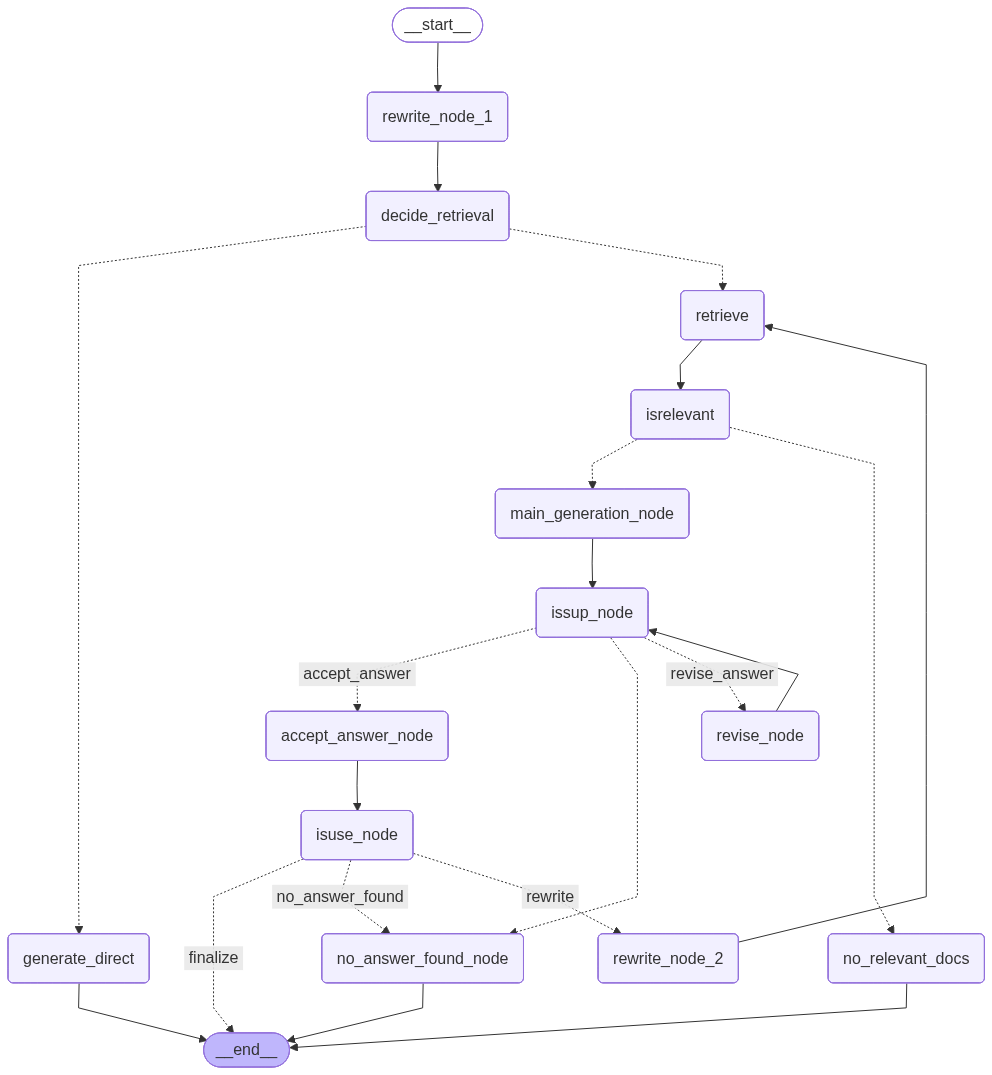

In [130]:
g = StateGraph(State)

g.add_node('rewrite_node_1',rewrite_node_1)

g.add_node("decide_retrieval", decide_retrieval_node)
g.add_node("generate_direct", generation_node)
g.add_node("retrieve", retrieve_node)
g.add_node('isrelevant',isrelevant_node)
g.add_node('main_generation_node',main_generation_node)
g.add_node("issup_node",issup_node)
g.add_node('revise_node',revise_node)
g.add_node('accept_answer_node',accept_answer_node)
g.add_node('isuse_node',isuse_node)
g.add_node('no_answer_found_node',no_answer_found_node)
g.add_node('no_relevant_docs', no_relevant_docs) 
g.add_node('rewrite_node_2',rewrite_node_2)





g.add_edge(START,'rewrite_node_1')
g.add_edge('rewrite_node_1', "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)
g.add_edge('retrieve','isrelevant')

g.add_conditional_edges(
    'isrelevant',
    route_after_relevance,
    {'no_relevant_docs':'no_relevant_docs','main_generation_node':'main_generation_node'}
    )

g.add_edge("main_generation_node",'issup_node') 

g.add_conditional_edges(
    'issup_node',
    route_after_issup,
    {'accept_answer':'accept_answer_node','revise_answer':'revise_node','no_answer_found_node':'no_answer_found_node'}
)

g.add_edge('revise_node','issup_node')
g.add_edge('accept_answer_node','isuse_node') 

g.add_conditional_edges(
    'isuse_node',
    route_after_isuse,
    {
        'finalize': END,
        'rewrite':'rewrite_node_2',
        'no_answer_found':'no_answer_found_node'
    }
    )
g.add_edge('rewrite_node_2','retrieve')
g.add_edge('no_answer_found_node',END)
g.add_edge('no_relevant_docs', END)



app = g.compile()

app


In [136]:
result = app.invoke(
    {
        "question": "jony ke ki okre",
        "need_retrieval": False,
        'relevant_docs':'',
        "docs": [],
        'retries':0,
        'issup': '',
        'evidence':'',
        "answer": "",
        'isuse': '',
        'use_reason':'',
        'retrieval_query': '',
        'rewrite_tries':0
    }
)
print('question: ',result['question'])
print('need retrieval: ',result['need_retrieval'])
print('len: ',len(result['docs']))
print('relevant docs: ',result['relevant_docs'])
print('relevant docs len: ',len(result['relevant_docs']))
print('issup: ',result['issup'])
print('retries: ',result['retries'])
print('evidence: ',result['evidence'])
print('isuse: ',result['isuse'])
print('rewrite retries: ',result['rewrite_tries'])
print('rewrite query: ',result['retrieval_query'])
print('isuse reason: ',result['use_reason'])
print('answer: ',result['answer'])







question:  Jony ke details information
need retrieval:  True
len:  10
relevant docs:  []
relevant docs len:  0
issup:  
retries:  0
evidence:  
isuse:  
rewrite retries:  0
rewrite query:  
isuse reason:  
answer:  I dont Know,No relevant document found


In [138]:
print('rewrite retries: ',result['docs'])

rewrite retries:  [Document(id='0ab1f47e-305a-4c7c-ab48-13d5c63a3a89', metadata={'phone': '০১৭৯৩-০০৯৬৬৭', 'designation': 'ইনস্ট্রাক্টর (টেক/ফুড)', 'context_text': 'রওনক জাহান হলেন (চাঁপাইনবাবগঞ্জ পলিটেকনিক ইনস্টিটিউট / CNPI)-এর একজন ইন্সট্রাক্টর। তার পদবি হলো ইনস্ট্রাক্টর (টেক/ফুড)। তিনি ফুড বিভাগে কর্মরত আছেন। তার সাথে যোগাযোগ করতে পারবেন এই নম্বরে: ০১৭৯৩-০০৯৬৬৭। রওনক জাহান-এর ফোন নম্বর ০১৭৯৩-০০৯৬৬৭। যদি কেউ ফুড বিভাগের শিক্ষকদের তথ্য জানতে চান, তাহলে রওনক জাহান (ইনস্ট্রাক্টর (টেক/ফুড)) একজন গুরুত্বপূর্ণ যোগাযোগ ব্যক্তি।', 'seq_num': 14, 'dipertment': 'Food', 'name': 'রওনক জাহান', 'doc_type': 'teachers info', 'source': 'G:\\Genarative-AI\\Self Rag\\Document\\teachers_data.json'}, page_content='রওনক জাহান হলেন (চাঁপাইনবাবগঞ্জ পলিটেকনিক ইনস্টিটিউট / CNPI)-এর একজন ইন্সট্রাক্টর। তার পদবি হলো ইনস্ট্রাক্টর (টেক/ফুড)। তিনি ফুড বিভাগে কর্মরত আছেন। তার সাথে যোগাযোগ করতে পারবেন এই নম্বরে: ০১৭৯৩-০০৯৬৬৭। রওনক জাহান-এর ফোন নম্বর ০১৭৯৩-০০৯৬৬৭। যদি কেউ ফুড বিভাগের শিক্ষকদের তথ্য জানতে চান, তাহলে রওন

In [96]:
print('rewrite query: ',result['question'])

rewrite query:  Md. Kausar Ali subject class details
